# Model comparison and validation

**Navigation**: [← Previous: Bayesian Hierarchical Model](05_bayesian.ipynb)

Direct vs EBLUP vs Bayesian vs ONS published model-based estimates, with shrinkage diagnostics and local-authority choropleths.


In [1]:

import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from IPython.display import HTML, display
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

PROJ_DIR = Path('.').resolve()
if not (PROJ_DIR / 'sae_utils.py').exists():
    PROJ_DIR = Path('projects/small-area-estimation').resolve()
if str(PROJ_DIR) not in sys.path:
    sys.path.insert(0, str(PROJ_DIR))

from sae_utils import (
    load_panel, modelling_frame, design_matrix, eblup_fh, fh_reml_sigma_u,
    jackknife_mse, gibbs_fh, summarise_theta, posterior_predictive_y,
    rhat_split, coverage_rate, project_data_dir,
)

def display_plotly(fig):
    """Embed Plotly with CDN JS — fig.show() is blank in Jupyter Book HTML."""
    display(HTML(fig.to_html(include_plotlyjs='cdn', full_html=False)))

FIG_DIR = PROJ_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)
DATA_DIR = project_data_dir()
PANEL = load_panel()
MODEL = modelling_frame(PANEL)
print(f'Panel: {len(PANEL)} local authorities; modelling subset: {len(MODEL)}')
print(f'Period (APS / ONS model-based): {PANEL["direct_period"].dropna().iloc[0]}')


Panel: 348 local authorities; modelling subset: 136
Period (APS / ONS model-based): Apr 2025-Mar 2026


## Putting four estimators on the same map

For each LA in the modelling subset we now have:

1. **Direct** APS rate $y_i$ with Wald interval from the published CI;
2. **EBLUP** $\hat\theta}_i$ with Datta–Lahiri MSE;
3. **Bayesian** posterior mean and 95% central interval (Gibbs);
4. **ONS model-based** rate, the production figure for the same period.

ONS is not truth. It is a competing (and more elaborate) estimate of the same $\theta_i$. Close agreement means we have recovered the public-data skeleton of their model; systematic disagreement points to benchmarking, extra covariates, temporal smoothing, or a different variance function.

In [2]:
eblup = eblup_fh(MODEL, covariates=['claimant_rate'])
gibbs = gibbs_fh(MODEL, covariates=['claimant_rate'], draws=4000, burn=1000, thin=2, seed=42)
bayes = summarise_theta(gibbs['theta'], index=MODEL.index)
cmp = eblup.copy()
cmp = cmp.join(bayes)
cmp['direct_se'] = cmp['direct_rate_ci'] / 1.96
cmp['direct_lo'] = cmp['direct_rate'] - 1.96 * cmp['direct_se']
cmp['direct_hi'] = cmp['direct_rate'] + 1.96 * cmp['direct_se']

def metrics(a, b):
    d = a - b
    return pd.Series({
        'bias': d.mean(),
        'MAE': d.abs().mean(),
        'RMSE': np.sqrt((d**2).mean()),
        'corr': np.corrcoef(a, b)[0, 1],
    })

rows = {
    'Direct vs ONS': metrics(cmp['direct_rate'], cmp['ons_mb_rate']),
    'EBLUP vs ONS': metrics(cmp['eblup'], cmp['ons_mb_rate']),
    'Bayes vs ONS': metrics(cmp['bayes_mean'], cmp['ons_mb_rate']),
    'EBLUP vs Bayes': metrics(cmp['eblup'], cmp['bayes_mean']),
}
tab = pd.DataFrame(rows).T.round(3)
print(tab.to_string())
print('\nONS interval coverage of our EBLUP (where ONS CI exists):')
has = cmp['ons_mb_rate_ci'].notna()
print('share of EBLUPs inside ONS 95% CI:',
      coverage_rate(cmp.loc[has, 'eblup'],
                    cmp.loc[has, 'ons_mb_rate'] - cmp.loc[has, 'ons_mb_rate_ci'],
                    cmp.loc[has, 'ons_mb_rate'] + cmp.loc[has, 'ons_mb_rate_ci']))
tab


                 bias    MAE   RMSE   corr
Direct vs ONS   0.494  1.006  1.239  0.803
EBLUP vs ONS    0.136  0.427  0.530  0.923
Bayes vs ONS    0.130  0.421  0.523  0.925
EBLUP vs Bayes  0.006  0.020  0.025  1.000

ONS interval coverage of our EBLUP (where ONS CI exists):
share of EBLUPs inside ONS 95% CI: 0.983739837398374


,bias,MAE,RMSE,corr
Direct vs ONS,0.494,1.006,1.239,0.803
EBLUP vs ONS,0.136,0.427,0.530,0.923
Bayes vs ONS,0.130,0.421,0.523,0.925
EBLUP vs Bayes,0.006,0.020,0.025,1.000


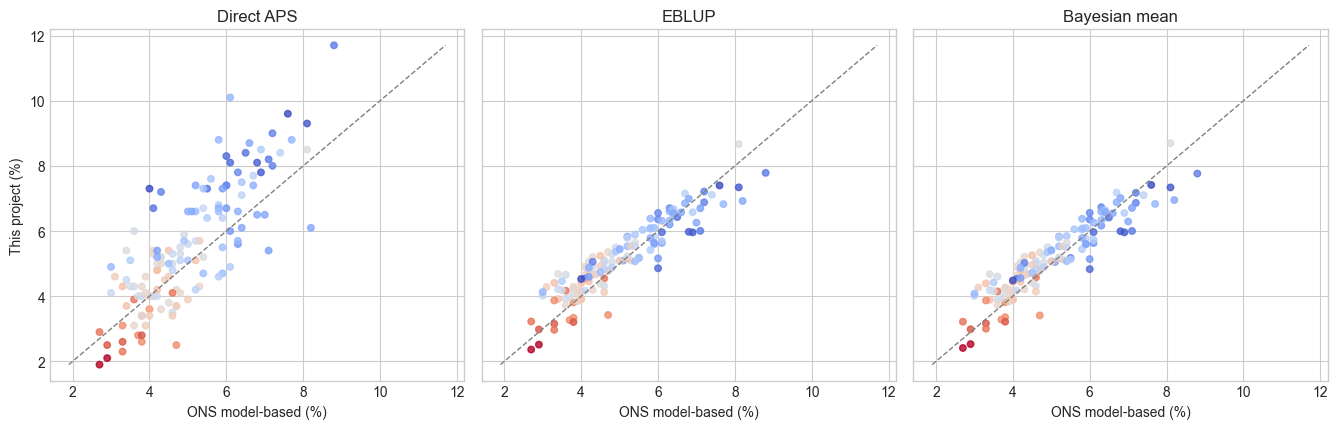

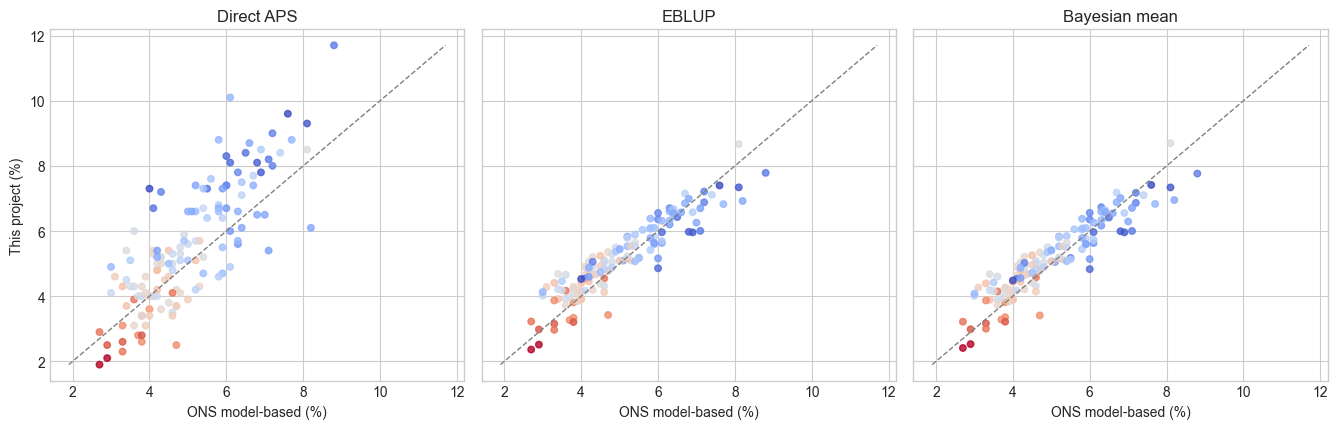

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4), sharex=True, sharey=True)
pairs = [
    ('direct_rate', 'Direct APS'),
    ('eblup', 'EBLUP'),
    ('bayes_mean', 'Bayesian mean'),
]
lims = [cmp[['direct_rate','eblup','bayes_mean','ons_mb_rate']].min().min(),
        cmp[['direct_rate','eblup','bayes_mean','ons_mb_rate']].max().max()]
for ax, (col, lab) in zip(axes, pairs):
    ax.scatter(cmp['ons_mb_rate'], cmp[col], s=22, alpha=0.8, c=cmp['gamma'], cmap='coolwarm')
    ax.plot(lims, lims, '--', color='grey', lw=1)
    ax.set_xlabel('ONS model-based (%)')
    ax.set_title(lab)
    ax.set_ylabel('This project (%)' if ax is axes[0] else '')
fig.tight_layout()
fig.savefig(FIG_DIR / '06_vs_ons_scatter.png', dpi=120)
fig


## Where they diverge

Largest $|\hat{\theta}^{\mathrm{EBLUP}} - \hat{\theta}^{\mathrm{ONS}}|$ areas are the interesting residuals: possible extra ONS covariates, regional benchmarking, or a different $\psi_i$.

In [4]:
cmp['abs_diff_ons'] = (cmp['eblup'] - cmp['ons_mb_rate']).abs()
cmp['signed_diff'] = cmp['eblup'] - cmp['ons_mb_rate']
print(cmp.nlargest(8, 'abs_diff_ons')[
    ['GEOGRAPHY_NAME','country','direct_rate','eblup','bayes_mean','ons_mb_rate','gamma','psi']
].round(2).to_string(index=False))


        GEOGRAPHY_NAME  country  direct_rate  eblup  bayes_mean  ons_mb_rate  gamma  psi
Windsor and Maidenhead  England          5.4   4.68        4.67          3.4   0.45 1.15
  Barking and Dagenham  England          6.1   6.92        6.95          8.2   0.29 2.34
   Newcastle upon Tyne  England          2.5   3.42        3.41          4.7   0.62 0.59
                Dorset  England          4.6   4.28        4.27          3.1   0.50 0.94
  Richmond upon Thames  England          8.3   4.86        4.83          6.0   0.19 3.96
         Aberdeenshire Scotland          4.9   4.13        4.07          3.0   0.32 2.04
              Cornwall  England          4.3   4.41        4.39          3.3   0.53 0.84
                Merton  England          8.2   6.00        6.00          7.1   0.22 3.37


## Interval comparison

If Bayes is doing its job, credible intervals should be **narrower** than direct Wald intervals, especially at small $\gamma_i$, and roughly comparable to EBLUP MSE intervals. They will not match ONS intervals unless the production variance function is the same.

width_direct    4.60
width_eblup     3.03
width_bayes     2.96
dtype: float64


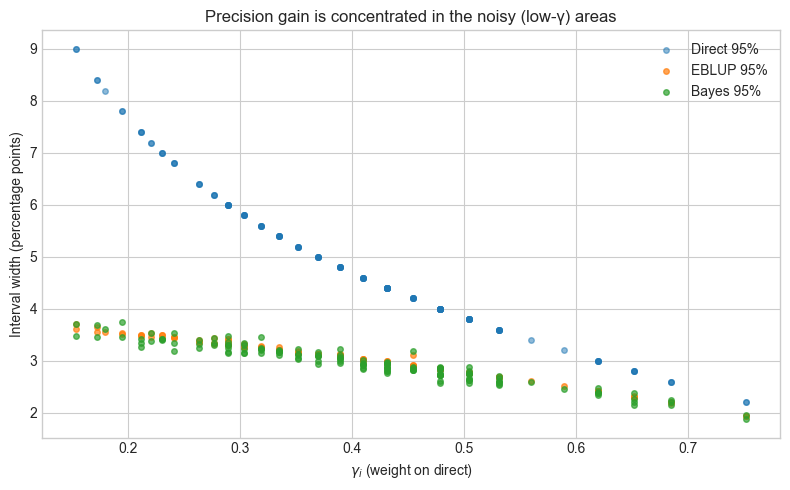

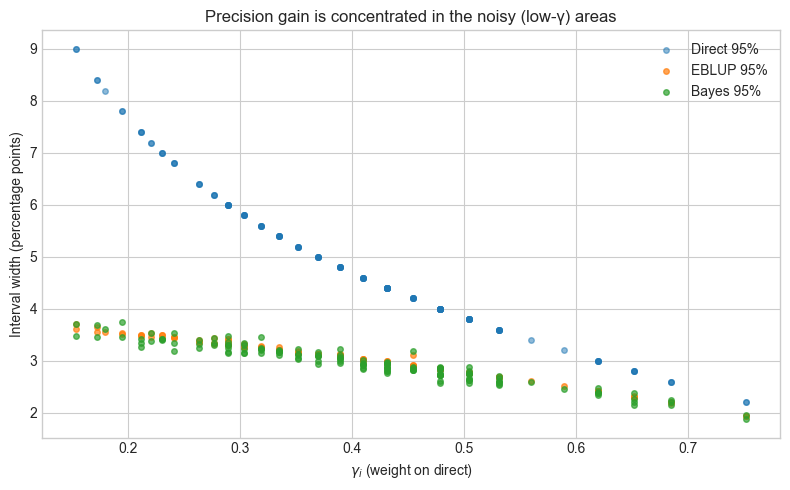

In [5]:
cmp['width_direct'] = cmp['direct_hi'] - cmp['direct_lo']
cmp['width_eblup'] = cmp['eblup_ci_hi'] - cmp['eblup_ci_lo']
cmp['width_bayes'] = cmp['bayes_ci_hi'] - cmp['bayes_ci_lo']
print(cmp[['width_direct','width_eblup','width_bayes']].median().round(2))
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(cmp['gamma'], cmp['width_direct'], s=16, alpha=0.5, label='Direct 95%')
ax.scatter(cmp['gamma'], cmp['width_eblup'], s=16, alpha=0.7, label='EBLUP 95%')
ax.scatter(cmp['gamma'], cmp['width_bayes'], s=16, alpha=0.7, label='Bayes 95%')
ax.set_xlabel(r'$\gamma_i$ (weight on direct)')
ax.set_ylabel('Interval width (percentage points)')
ax.set_title('Precision gain is concentrated in the noisy (low-γ) areas')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / '06_interval_width.png', dpi=120)
fig


## Choropleths

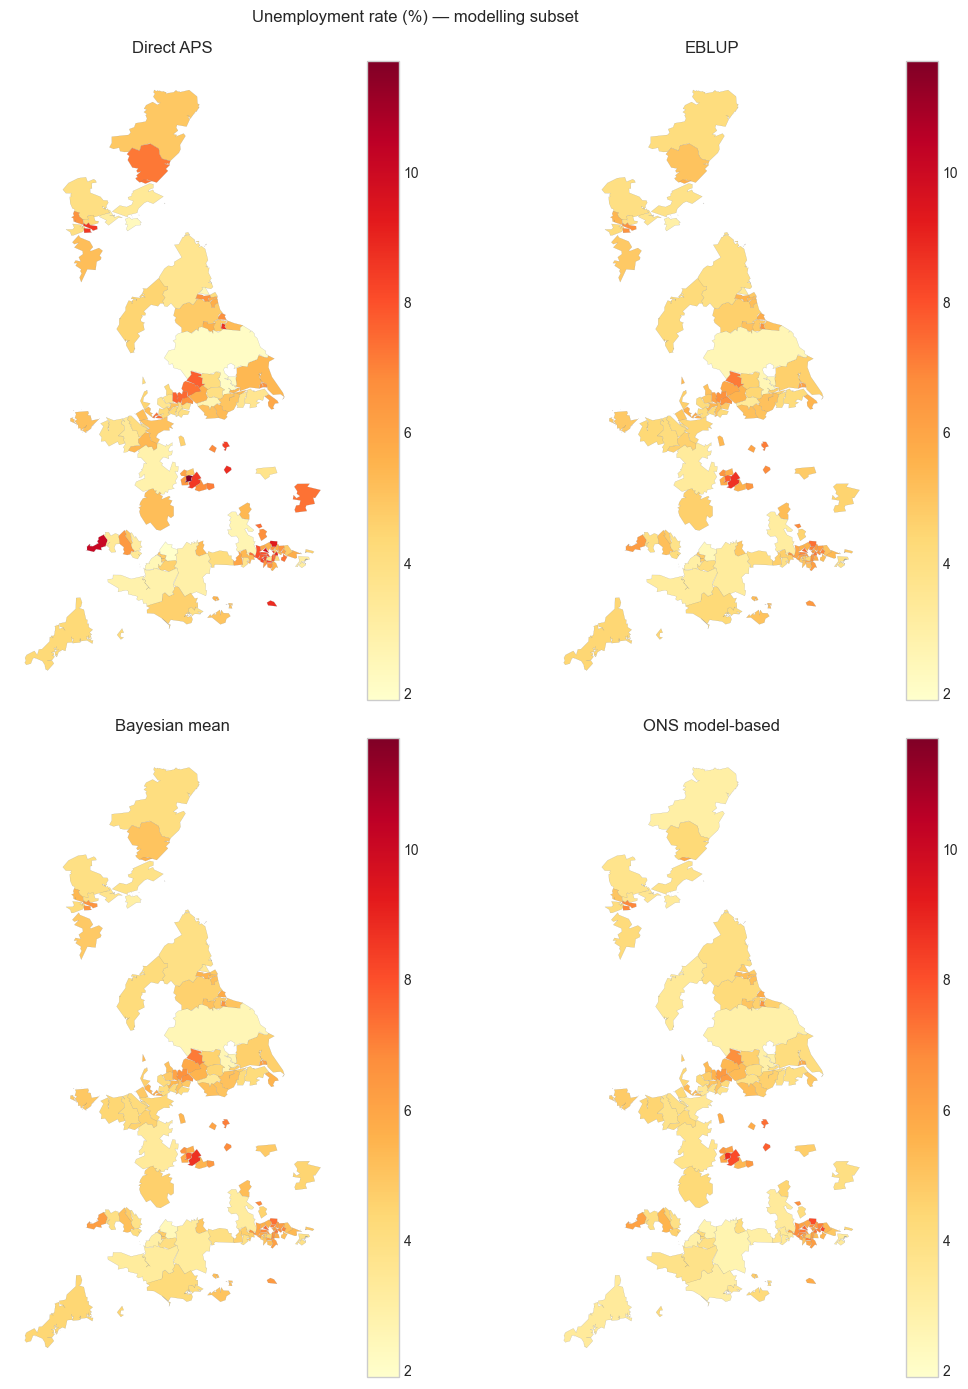

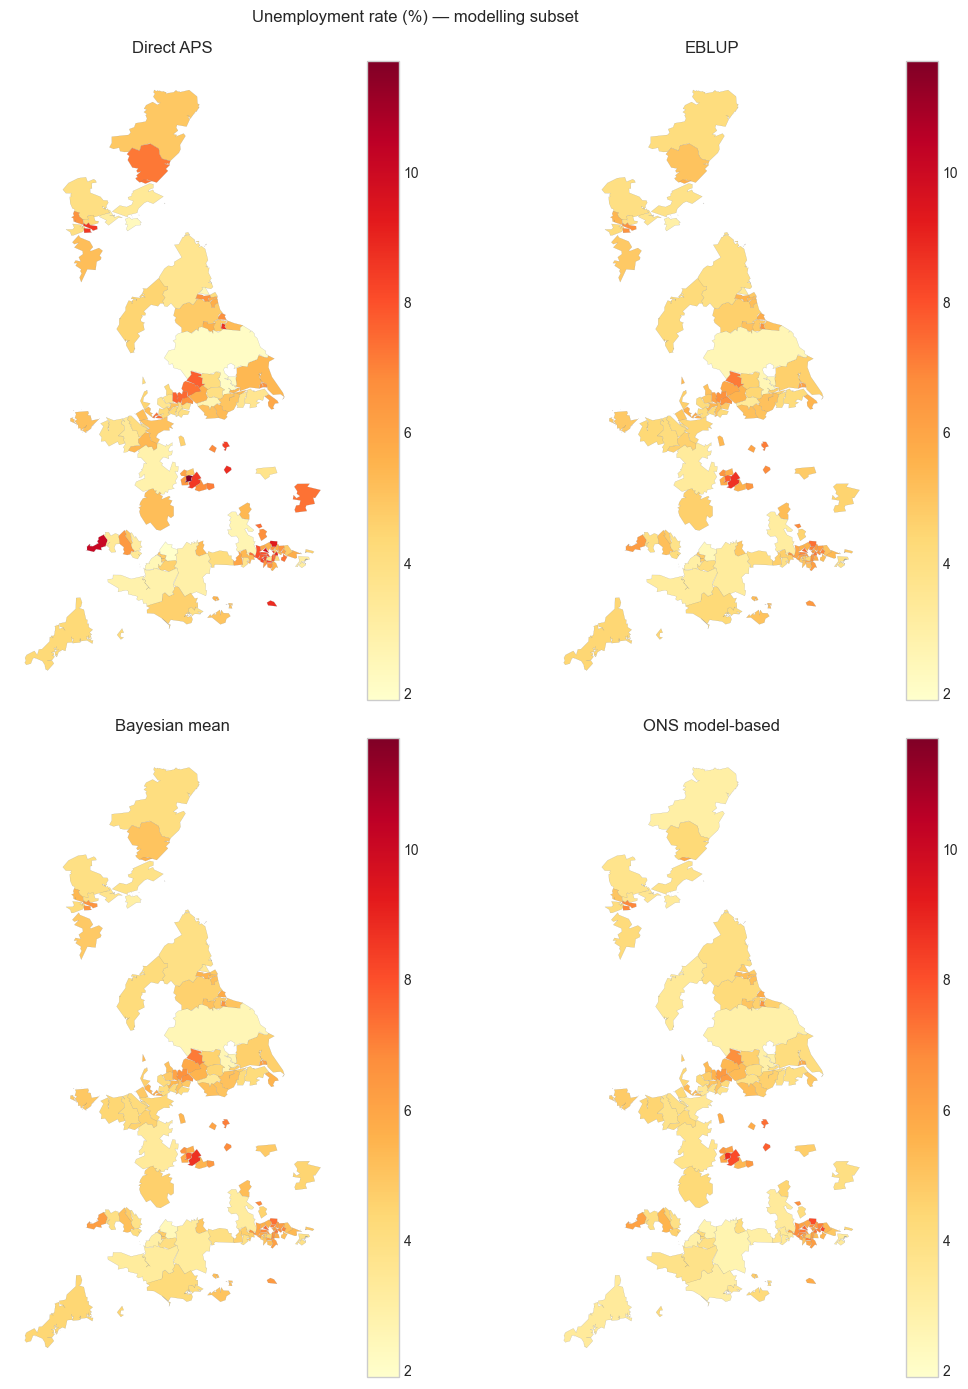

In [6]:
import geopandas as gpd

geo_path = DATA_DIR / 'la_boundaries.geojson'
gdf = gpd.read_file(geo_path)
gdf = gdf.merge(
    cmp[['GEOGRAPHY_CODE','GEOGRAPHY_NAME','direct_rate','eblup','bayes_mean','ons_mb_rate','gamma','signed_diff']],
    on='GEOGRAPHY_CODE', how='left',
)
plot_df = gdf.dropna(subset=['eblup'])

fig, axes = plt.subplots(2, 2, figsize=(12, 14))
specs = [
    (axes[0,0], 'direct_rate', 'Direct APS'),
    (axes[0,1], 'eblup', 'EBLUP'),
    (axes[1,0], 'bayes_mean', 'Bayesian mean'),
    (axes[1,1], 'ons_mb_rate', 'ONS model-based'),
]
vmin = plot_df[['direct_rate','eblup','bayes_mean','ons_mb_rate']].min().min()
vmax = plot_df[['direct_rate','eblup','bayes_mean','ons_mb_rate']].max().max()
for ax, col, title in specs:
    plot_df.plot(column=col, ax=ax, cmap='YlOrRd', vmin=vmin, vmax=vmax, linewidth=0.1, edgecolor='grey', legend=True)
    ax.set_axis_off()
    ax.set_title(title)
fig.suptitle('Unemployment rate (%) — modelling subset', y=0.99)
fig.tight_layout()
fig.savefig(FIG_DIR / '06_choropleth_rates.png', dpi=120)
fig


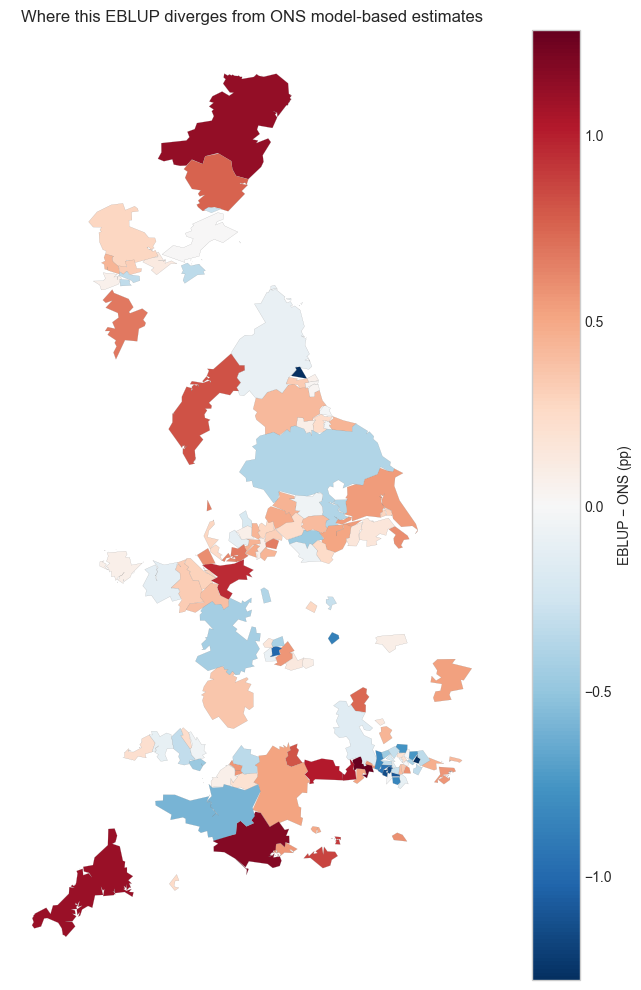

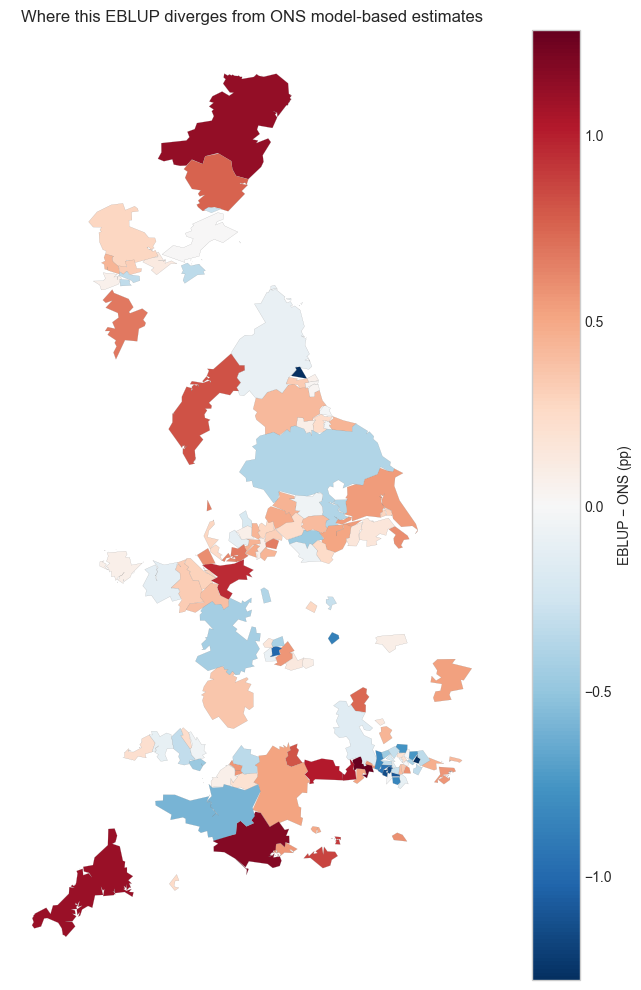

In [7]:
fig, ax = plt.subplots(figsize=(8, 10))
plot_df.plot(column='signed_diff', ax=ax, cmap='RdBu_r', legend=True,
             linewidth=0.1, edgecolor='grey',
             legend_kwds={'label': 'EBLUP − ONS (pp)'})
ax.set_axis_off()
ax.set_title('Where this EBLUP diverges from ONS model-based estimates')
fig.tight_layout()
fig.savefig(FIG_DIR / '06_choropleth_diff.png', dpi=120)
fig


## Interactive residual view

In [8]:
fig = px.scatter(
    cmp, x='ons_mb_rate', y='eblup',
    color='gamma', size='psi',
    hover_name='GEOGRAPHY_NAME',
    hover_data={'direct_rate':':.1f', 'bayes_mean':':.1f', 'country': True},
    labels={'ons_mb_rate': 'ONS model-based (%)', 'eblup': 'EBLUP (%)', 'gamma': 'γ'},
    title='EBLUP vs ONS (size = ψ, colour = γ)',
    color_continuous_scale='RdBu',
)
lims = [cmp[['ons_mb_rate','eblup']].min().min(), cmp[['ons_mb_rate','eblup']].max().max()]
fig.add_trace(go.Scatter(x=lims, y=lims, mode='lines', name='y = x',
                         line=dict(dash='dash', color='grey')))
display_plotly(fig)


## When model-based estimation helps

The payoff is concentrated where $\gamma_i$ is small: the EBLUP and Bayes intervals are shorter than the direct interval, and both sit closer to ONS than $y_i$ does. Where $\gamma_i \approx 1$, all four series essentially reproduce the APS — as they should. Publishing a model-based figure for Birmingham is a different proposition from publishing one for a small district, and the shrinkage factor makes that distinction **visible**.

Disagreement with ONS, where it occurs, is more likely

- **benchmarking**: ONS may calibrate LA estimates to regional APS totals, which our independent FH does not;
- **the variance function**: we take published CIs as $\psi_i$, ONS estimates $\psi_i$ from survey design internally;
- **covariates and dynamics**: a single claimant snapshot vs a production model that can include lagged rates or additional admin sources;
- **geography**: mid-year boundary changes and GB vs UK coverage.

Those gaps are expected. The useful result is that a transparent, reproducible Fay–Herriot on open aggregates recovers the same **map** and the same **shrinkage pattern** as the official series.

## Key takeaways

- EBLUP and Bayes posterior means are nearly interchangeable at this $m$; the Bayesian contribution is the posterior of $\sigma_u^2$ and honest propagation into $\theta_i$ intervals.
- Both improve on the direct estimator as a predictor of the ONS series, which is the right check for an open reimplementation.
- Model-based estimation earns its keep in the high-$\psi_i$ tail — exactly the areas the APS cannot publish with a straight face.

---

**Navigation**: [← Previous: Bayesian Hierarchical Model](05_bayesian.ipynb)
